#### *PhotoDissociation Region Toolbox Notebooks*
-------------------------------------------------------------
## Example X: Using Edge-on PDR Models to fit emission maps of the Horsehead.

This example shows use the PDRT Toolbox to determine the PDR radiation field $G_0$
 and hydrogen nucleus volume density $n$ for an edge-on PDR using maps of the Horsehead presented in [Pabst et al. (2017, A&A, 606, A29)](https://ui.adsabs.harvard.edu/abs/2017A%26A...606A..29P/abstract).  The observations are integrated intensity maps in $^{12}$CO(1-0), $^{13}$CO(1-0), $I_{FIR}$, and [C II] 158 $\mu$m, smoothed to a common 30$^{\prime\prime}$ beam.   To fit the data, we use the 75$\degree$ viewing angle Wolfire-Kaufman model.

#### References for map data: 
 
-  $^{12}$CO(1-0), $^{13}$CO(1-0) - [Pety et al. (2017, A&A, 599, A98)](https://ui.adsabs.harvard.edu/abs/2017A%26A...599A..98P/abstract)
-  $I_{FIR}$ - [Lombardi et al. (2014, A&A, 566, A45)](https://ui.adsabs.harvard.edu/abs/2014A%26A...566A..45L/abstract)
-  [C II] - [Pabst et al. (2017, A&A, 606, A29)](https://ui.adsabs.harvard.edu/abs/2017A%26A...606A..29P/abstract)

In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pylab as pl
from copy import deepcopy
from pdrtpy.measurement import Measurement
from pdrtpy.modelset import ModelSet
from pdrtpy.tool.lineratiofit import LineRatioFit
from pdrtpy.plot.lineratioplot import LineRatioPlot

------

#### Create a color map and plot parameters to make a a publication quality image
This uses a combined gray and color map.  
Thanks to the [ACES project](https://github.com/ACES-CMZ/reduction_ACES/blob/main/aces/visualization/figure_configuration.py).

In [2]:
steps = 64
colors1 = pl.cm.gray_r(np.linspace(0., 1, steps))
colors2 = pl.cm.hot(np.linspace(0, 1, steps))
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

In [3]:
rcParams = {}
rcParams["xtick.major.size"] = 7
rcParams["xtick.minor.size"] = 4
rcParams["ytick.major.size"] = 7
rcParams["ytick.minor.size"] = 4
rcParams['font.size'] = 12
rcParams['axes.linewidth'] =1.5

---------------------------

### Read in the data. 

In [4]:
datadir='../data'
maps = {}
data =  {
    "CII_158": (1900.537*u.GHz, "K km s-1"),
    "FIR": (None, "erg s-1 cm-2 sr-1"),
    "CO_10": (115.2712*u.GHz, "K km s-1"),
    "13CO_10": (110.20137*u.GHz, "K km s-1"),
}
for k,v in data.items():
    maps[k] = Measurement.read(f"{datadir}/orionb_{k}.fits",units=v[1],restfreq=v[0], identifier=k)

### Optionally mask the data where the S/N is low to prevent poor fits.

In [5]:
domask = True
if domask:
    mask1 = np.ma.masked_where(maps["CII_158"].data<9,maps["CII_158"]).mask
    mask2 = np.ma.masked_where(maps["CO_10"].data<15,maps["CO_10"]).mask
    mask3 = np.ma.masked_where(maps["13CO_10"].data<2,maps["13CO_10"]).mask
    final_mask = combined_mask = np.any(np.stack([mask1,mask2,mask3]), axis=0)
for m in maps:
    maps[m].mask = deepcopy(final_mask)

### Display the data

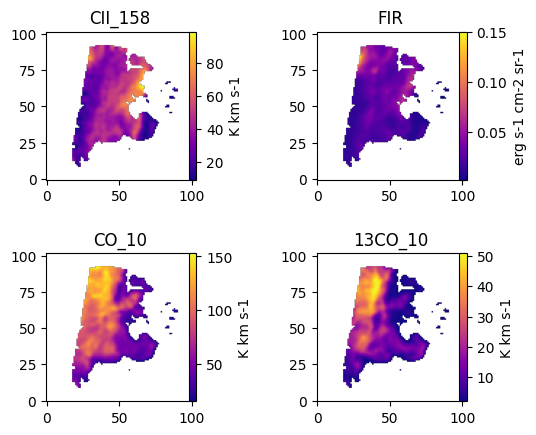

In [6]:
axis=dict.fromkeys(list(maps.keys()))
figure,((axis['CII_158'],axis['FIR']),(axis['CO_10'],axis['13CO_10']))=plt.subplots(2,2)
for m in maps:
    im=axis[m].imshow(maps[m],origin='lower',cmap='plasma')
    divider = make_axes_locatable(axis[m])
    cax = divider.append_axes('right', size='5%', pad=-0.05)
    figure.colorbar(im,ax=axis[m],cax=cax,label=data[m][1])
    axis[m].set_title(m)
    plt.subplots_adjust(wspace=0.2)
    plt.subplots_adjust(hspace=0.5)

## Now fit the data to determine $n$ and $G_0$.
Since the Horsehead is edge-on (or nearly so), use viewing angle of 75 degrees to fit the data.

In [7]:
wkedge= ModelSet("wk2020",z=1, losangle=75)

In [8]:
mapfit = LineRatioFit(wkedge,list(maps.values()))

In [9]:
mapfit.run()

Converting K km/s to erg / (s sr cm2) using Factor = +7.035E-06 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +7.035E-06 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +1.570E-09 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +7.035E-06 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +1.372E-09 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +1.372E-09 g / (K cm s2)
Converting K km/s to erg / (s sr cm2) using Factor = +1.570E-09 g / (K cm s2)


  0%|          | 0/10404 [00:00<?, ?it/s]

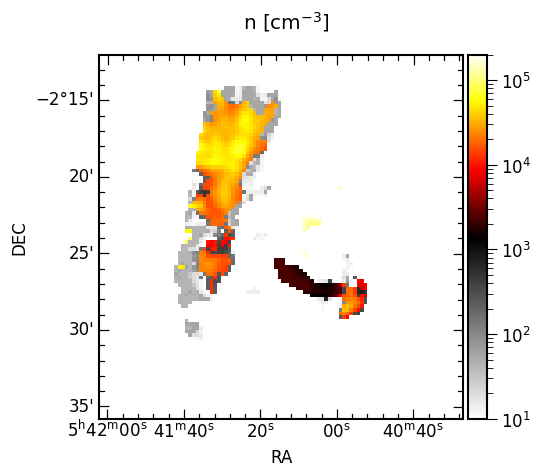

In [10]:
mapplot = LineRatioPlot(mapfit)
mapplot._plt.rcParams.update(rcParams)
mapplot.density(norm='log',cmap=mymap,vmax=2E5)
mapplot.savefig('Horsehead_density.png',dpi=300,bbox_inches='tight')

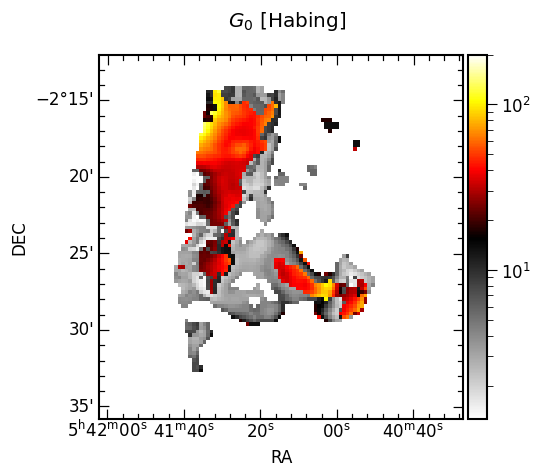

In [14]:
mapplot.radiation_field(norm='log',cmap=mymap,units="Habing",vmax=200)
mapplot.savefig('Horsehead_G0.png',dpi=300,bbox_inches='tight')